# EEPAS Italy Results: Visualization and PyCSEP Evaluation

## 📚 Overview

This notebook demonstrates the **complete evaluation pipeline** for EEPAS forecasts using the **PyCSEP** (Collaboratory for the Study of Earthquake Predictability) framework.

### What This Notebook Does

1. **Load EEPAS and PPE Forecasts**
2. **Visualize Forecast Maps**: Plot spatial distribution of seismicity rates with observed earthquakes
3. **Run PyCSEP Consistency Tests**: Evaluate forecast performance using standardized tests
4. **Compare Models**: Quantitatively compare EEPAS vs. PPE using multiple scoring metrics

---

## 🎯 EEPAS Workflow Context

This notebook represents **Step 5** (Evaluation) in the EEPAS pipeline:

```
[Step 1] PPE Learning → a, d, s
[Step 2] Aftershock Fitting → ν, κ
[Step 3] EEPAS Learning → am, bm, Sm, at, bt, St, ba, Sa, u
[Step 4] Forecast Generation → PREVISIONI_3m_EEPAS_*.mat, PREVISIONI_3m_PPE_*.mat
[Step 5] Evaluation (this notebook) → PyCSEP tests + visualization
```

---

## 📊 Configuration and Data

### Input Files (from `results_italy_causal_ew0/`)

| File | Description | Usage |
|------|-------------|-------|
| `PREVISIONI_3m_EEPAS_2012_2022.mat` | EEPAS forecast (2012-2022) | Main forecast to evaluate |
| `PREVISIONI_3m_PPE_2012_2022.mat` | PPE forecast (2012-2022) | Baseline model for comparison |
| `Fitted_par_EEPAS_1990_2012.csv` | Learned EEPAS parameters | Reference for interpretation |
| `Fitted_par_PPE_1990_2012.csv` | Learned PPE parameters | Reference for interpretation |

### Catalog Files

- **HORUS_Italy_filtered.mat**: Observed earthquakes in testing region (177 cells)
- **CELLE_ter.mat**: Grid cell definitions (177 cells, ~42.43 km × 42.43 km each)
- **CPTI15.mat**: Italian polygon boundary (for spatial filtering)

### Key Parameters

```json
{
  "forecastStartYear": 2012,
  "forecastEndYear": 2022,
  "forecastPeriodDays": 91.31,  // 3-month periods
  "modelParams": {
    "mT": 5.0,                   // Target magnitude threshold
    "m0": 2.45                    // Completeness magnitude
  }
}
```

**Result**:
- **40 forecast periods** (10 years ÷ 3 months ≈ 40 periods)
- **Magnitude bins**: M ≥ 5.0 in 0.1 increments (25 bins total)
- **Spatial bins**: 177 grid cells
- **Total space-magnitude bins**: 177 × 25 = 4,425 bins

---

## 📝 Notebook Structure

1. **Data Loading**: Load forecasts, grid definitions, and catalog
2. **Forecast Visualization**: Plot spatial maps with observed earthquakes
3. **EEPAS Evaluation**: Run all PyCSEP tests on EEPAS forecast
4. **PPE Evaluation**: Run all PyCSEP tests on PPE forecast  
5. **Model Comparison**: Compare performance using multiple metrics

---

## ⚠️ Important Notes

1. **Coordinate Transformations**:
   - Forecasts are in RDN2008 (EPSG:7794) projection
   - PyCSEP requires WGS84 (lat/lon)
   - We perform coordinate transformation for each grid cell

2. **Magnitude Threshold**:
   - Forecasts use M ≥ 5.0 (mT in config)
   - Catalog filtering must match: `magnitude >= 4.95` (to include M 5.0-5.05 bin)

3. **Time Period**:
   - Forecast: 2012-01-01 to 2021-12-31
   - Actual evaluation: 2012-01-25 to 2018-12-26 (based on available catalog)

4. **PyCSEP Patch**:
   - We patch `csep/core/regions.py` to fix polygon boundary handling
   - See `patch_pycsep.py` for details

---

Let's begin!

In [ ]:
!pip install pycsep -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 12.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.
google-adk 1.19.0 requires sqlalchemy<3.0.0,>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/HORUS_Italy_polygon_filtered.mat /content/
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/HORUS_Italy_RDN2008_polygon_filtered.mat /content/
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/HORUS_Italy_filtered.mat /content/
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/HORUS_Italy_RDN2008_filtered.mat /content/
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/EEPAS_CODE/CELLE_ter.mat /content/
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/EEPAS_CODE/CPTI15.mat /content/
!cp /content/drive/MyDrive/earth_src/src/EEPAS_Taiwan-main/src/analysis/dataset.py /content/
!cp /content/drive/MyDrive/earth_src/src/EEPAS_Taiwan-main/src/analysis/patch_pycsep.py /content/

In [ ]:
!cp /content/drive/MyDrive/results_italy_paper.zip /content/
!unzip /content/results_italy_paper.zip

Archive:  /content/results_italy_paper.zip
   creating: results_italy_paper_1round_full/
  inflating: results_italy_paper_1round_full/Fitted_par_aftershock_1990_2012.csv  
  inflating: results_italy_paper_1round_full/Fitted_par_EEPAS_1990_2012.csv  
  inflating: results_italy_paper_1round_full/Fitted_par_PPE_1990_2012.csv  
  inflating: results_italy_paper_1round_full/PREVISIONI_3m_EEPAS_2012_2022.mat  
  inflating: results_italy_paper_1round_full/PREVISIONI_3m_PPE_2012_2022.mat  


Here we modify /content/pycsep/csep/core/regions.py from `joined_poly.boundary.xy` to `joined_poly.envelope.boundary.coords.xy`

In [ ]:
!python patch_pycsep.py

Checking file: /usr/local/lib/python3.12/dist-packages/csep/core/regions.py
✅ Success: Code has been automatically replaced.


In [ ]:
import datetime
import sys
import os
import numpy as np
import pandas as pd
import scipy.io
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import cartopy
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

from pyproj import Transformer
from tqdm import tqdm
import csep
from csep.utils import time_utils
from csep.core import poisson_evaluations as poisson
from csep.core import binomial_evaluations as binomial
from csep.utils import plots
from csep.utils.stats import get_Kagan_I1_score
from csep.core.binomial_evaluations import binary_joint_log_likelihood_ndarray as jolib
from csep.core.poisson_evaluations import poisson_joint_log_likelihood_ndarray as jolip
from dataset import extract_period_forecast, create_subgrids_spatial, generate_all_periods_forecast, create_csep_forecast_file, calculate_date_range, get_top_earthquakes, my_custom_loader_function

In [ ]:
def _brier_score_ndarray(forecast, observations):
    """ Computes the brier (binary) score for spatial-magnitude cells
    using the formula:
    Q(Lambda, Sigma) = 1/N sum_{i=1}^N (Lambda_i - Ind(Sigma_i > 0 ))^2
    where Lambda is the forecast array, Sigma is the observed catalog, N the
    number of spatial-magnitude cells and Ind is the indicator function, which
    is 1 if Sigma_i > 0 and 0 otherwise.
    Args:
        forecast: 2d array of forecasted rates
        observations: 2d array of observed counts
    Returns
        brier: float, brier score
    """

    prob_success = 1 - scipy.stats.poisson.cdf(0, forecast)
    brier_cell = np.square(prob_success.ravel() - (observations.ravel() > 0))
    brier = -2 * brier_cell.sum()

    for n_dim in observations.shape:
        brier /= n_dim
    return brier

In [ ]:
# ==========================================
# 1. Input File & Parameter Settings
# ==========================================
# @title Input File Settings
forecast_file_name = '/content/results_italy_paper_1round_full/PREVISIONI_3m_PPE_2012_2022.mat'  # @param {type: "string"}
celle_file_name = '/content/CELLE_ter.mat'  # @param {type: "string"}

# Constant Settings: Number of regions, magnitude steps, and periods
num_regions = 177 # @param {type: "number"}
num_magnitude_steps = 25 # @param {type: "number"}

# ==========================================
# 2. Read and Transform Grid Definitions (CELLE_ter.mat)
# ==========================================
# ** Version (A): Convert Kilometers (EPSG:7794) to Lat/Lon (EPSG:4326) **
print(f"Reading grid definition file: {celle_file_name}")

try:
    mat_data = scipy.io.loadmat(celle_file_name)
    cells_data_km = mat_data['CELLESD'][:, :4]
    data_m = cells_data_km * 1000  # Convert km to meters
    transformer = Transformer.from_crs("EPSG:7794", "EPSG:4326", always_xy=True)

    print("\nConverting kilometer grid to Lat/Lon Bounding Box...")
    cells_lonlat = []

    for i in tqdm(range(len(data_m)), desc="Converting Grid"):
        x_min, x_max, y_min, y_max = data_m[i]
        corners_xy = [(x_min, y_min), (x_max, y_min), (x_min, y_max), (x_max, y_max)]

        # Transform coordinates
        lons, lats = transformer.transform([p[0] for p in corners_xy], [p[1] for p in corners_xy])

        lon_min_bbox = np.min(lons)
        lon_max_bbox = np.max(lons)
        lat_min_bbox = np.min(lats)
        lat_max_bbox = np.max(lats)

        cells_lonlat.append({
            'LON_0': lon_min_bbox,
            'LON_1': lon_max_bbox,
            'LAT_0': lat_min_bbox,
            'LAT_1': lat_max_bbox
        })

    cell_bounds = pd.DataFrame(cells_lonlat)

    print(f"\nSuccessfully converted {len(cell_bounds)} grid regions.")
    print("Bounding Box Example:")
    print(cell_bounds.head())

except Exception as e:
    print(f"Error: Unable to read or convert grid file {celle_file_name}: {e}")
    sys.exit(1)


# ==========================================
# 3. Read Forecast Data
# ==========================================
print(f"\nReading forecast data file: {forecast_file_name}")
forecast_mat = scipy.io.loadmat(forecast_file_name)
print("Variables in forecast file:", forecast_mat.keys())

# Determine the correct key for forecast data
forecast_key = 'PREVISIONI_3m'
if 'PREVISIONI_3m_less' in forecast_mat:
    forecast_key = 'PREVISIONI_3m_less'
elif 'PREVISIONI_3m' not in forecast_mat:
    potential_keys = [k for k in forecast_mat.keys() if not k.startswith('__')]
    if potential_keys:
        forecast_key = potential_keys[0]
    else:
        raise ValueError("No usable data variable found in forecast file.")

forecast_data = forecast_mat[forecast_key]
print(f"Forecast data shape: {forecast_data.shape}")
print(f"Variable name used: {forecast_key}")


# ==========================================
# 4. Create Magnitude Bins
# ==========================================
print("\nCreating Magnitude Bins...")
magnitude_bins = []
for i in range(num_magnitude_steps):
    mag_0 = 5.0 + 0.1 * i
    mag_1 = mag_0 + 0.1
    magnitude_bins.append((round(mag_0, 2), round(mag_1, 2)))


# ==========================================
# 5. Process and Execute
# ==========================================
process_mode = "both"  # @param ["single_period", "all_periods", "both"]
which_period = 1       # @param {type: "number"}

if process_mode in ["single_period", "both"]:
    print(f"\n--- Processing Single Period: Period {which_period} ---")

    # 1. Extract data for the specific period
    print(f"Extracting forecast data for period {which_period}...")
    # NOTE: 'extract_period_forecast' must be defined in your environment
    period_forecast = extract_period_forecast(which_period, forecast_data, num_magnitude_steps, magnitude_bins, num_regions, cell_bounds)

    # 2. Perform spatial downscaling (creates potentially duplicate grid points)
    # NOTE: 'create_subgrids_spatial' must be defined in your environment
    subgrid_data_raw = create_subgrids_spatial(period_forecast)

    # --- Aggregation Fix Start ---
    # 3. Aggregate duplicate grid points caused by BBox overlap
    print("Aggregating overlapping 0.1° grid points...")

    # Round coordinates to avoid floating-point precision issues before grouping
    subgrid_data_raw['LON_0'] = subgrid_data_raw['LON_0'].round(2)
    subgrid_data_raw['LAT_0'] = subgrid_data_raw['LAT_0'].round(2)

    # Group by the 0.1° grid origin and magnitude
    group_cols_simple = ['LON_0', 'LAT_0', 'MAG_0']

    # Define aggregation rules
    agg_funcs = {
        'RATE': 'sum',      # Sum the forecast rates
        'LON_1': 'first',   # Take the first value for other columns
        'LAT_1': 'first',
        'Z_0': 'first',
        'Z_1': 'first',
        'MAG_1': 'first',
        'FLAG': 'first',
        'PERIOD': 'first'   # Retain the PERIOD column
    }

    # 'subgrid_data' is the final, merged DataFrame
    subgrid_data = subgrid_data_raw.groupby(group_cols_simple, as_index=False).agg(agg_funcs)
    print(f"Raw grid points: {len(subgrid_data_raw)}, Unique grid points after aggregation: {len(subgrid_data)}")
    # --- Aggregation Fix End ---

    # 4. Sort
    subgrid_data.sort_values(by=['LON_0', 'LAT_0', 'MAG_0'], inplace=True)

    # 5. Export Files
    print("Exporting CSEP format file...")
    output_filename = f'output_forecast_{which_period}.dat'
    # NOTE: 'create_csep_forecast_file' must be defined in your environment
    create_csep_forecast_file(subgrid_data, output_filename)

    csv_filename = f'output_forecast_{which_period}_check.csv'
    subgrid_data.to_csv(csv_filename, index=False)

    print(f"Single period processing complete! Generated file: {output_filename}")
    print(f"Total 0.1° grid points: {len(subgrid_data)}")


if process_mode in ["all_periods", "both"]:
    print(f"\n--- Processing All Periods (Summed) ---")

    # 1. Generate and sum data for all periods
    # NOTE: 'generate_all_periods_forecast' must be defined in your environment
    summed_data = generate_all_periods_forecast(forecast_data, num_magnitude_steps, magnitude_bins, num_regions, cell_bounds)

    if not summed_data.empty:
        # 2. Sort
        summed_data.sort_values(by=['LON_0', 'LAT_0', 'MAG_0'], inplace=True)

        # 3. Export Files
        print("Exporting CSEP format file for all periods...")
        output_filename = 'output_forecast_all_periods_ppe.dat'
        create_csep_forecast_file(summed_data, output_filename)

        csv_filename = 'output_forecast_all_periods_check_ppe.csv'
        summed_data.to_csv(csv_filename, index=False)

        print(f"All periods processing complete! Generated file: {output_filename}")
        print(f"Total aggregated 0.1° grid points: {len(summed_data)}")
    else:
        print("Unable to generate forecast data. Please check input files and parameters.")

print("\n--- All processing completed ---")

Reading grid definition file: /content/CELLE_ter.mat

Converting kilometer grid to Lat/Lon Bounding Box...


Converting Grid: 100%|██████████| 177/177 [00:00<00:00, 20919.52it/s]


Successfully converted 177 grid regions.
Bounding Box Example:
       LON_0      LON_1      LAT_0      LAT_1
0  10.260386  10.827190  46.612373  47.001541
1  10.818853  11.381887  46.619403  47.005941
2  11.936222  12.494961  46.624359  47.007615
3   8.057811   8.634436  46.176091  46.575186
4  10.272662  10.835359  46.230301  46.619403

Reading forecast data file: /content/results_italy_paper_1round_full/PREVISIONI_3m_PPE_2012_2022.mat
Variables in forecast file: dict_keys(['__header__', '__version__', '__globals__', 'PREVISIONI_3m'])
Forecast data shape: (1000, 178)
Variable name used: PREVISIONI_3m

Creating Magnitude Bins...

--- Processing Single Period: Period 1 ---
Extracting forecast data for period 1...


Downscaling large grids to 0.1°×0.1° sub-grids (Using spatial method)...


Processing sub-grids: 100%|██████████| 4425/4425 [00:02<00:00, 1481.76it/s]


...

Processing period 39 of 40...
Downscaling large grids to 0.1°×0.1° sub-grids (Using spatial method)...


Processing sub-grids: 100%|██████████| 4425/4425 [00:04<00:00, 1069.50it/s]


Processing period 40 of 40...
Downscaling large grids to 0.1°×0.1° sub-grids (Using spatial method)...


Processing sub-grids: 100%|██████████| 4425/4425 [00:03<00:00, 1442.36it/s]


Summing forecast rates across periods...
Original data points: 3684000, Summed data points: 88500
Exporting CSEP format file for all periods...
Created CSEP-compatible file: output_forecast_all_periods_ppe.dat
All periods processing complete! Generated file: output_forecast_all_periods_ppe.dat
Total aggregated 0.1° grid points: 88500

--- All processing completed ---


In [ ]:
# ==========================================
# 1. Input File & Parameter Settings
# ==========================================
# @title Input File Settings
forecast_file_name = '/content/results_italy_paper_1round_full/PREVISIONI_3m_EEPAS_2012_2022.mat'  # @param {type: "string"}
celle_file_name = '/content/CELLE_ter.mat'  # @param {type: "string"}

# Constant Settings: Number of regions, magnitude steps, and periods
num_regions = 177 # @param {type: "number"}
num_magnitude_steps = 25 # @param {type: "number"}

# ==========================================
# 2. Read and Transform Grid Definitions (CELLE_ter.mat)
# ==========================================
# ** Version (A): Convert Kilometers (EPSG:7794) to Lat/Lon (EPSG:4326) **
print(f"Reading grid definition file: {celle_file_name}")
try:
    mat_data = scipy.io.loadmat(celle_file_name)
    cells_data_km = mat_data['CELLESD'][:, :4]
    data_m = cells_data_km * 1000  # Convert to meters
    transformer = Transformer.from_crs("EPSG:7794", "EPSG:4326", always_xy=True)

    print("\nConverting kilometer grid to Lat/Lon Bounding Box...")
    cells_lonlat = []

    # REVERTED TO ORIGINAL LOGIC: Loop through all items to transform all 4 corners
    # This ensures the Bounding Box covers the exact same area as your original script.
    for i in tqdm(range(len(data_m)), desc="Converting Grid"):
        x_min, x_max, y_min, y_max = data_m[i]

        # Define all 4 corners
        corners_xy = [(x_min, y_min), (x_max, y_min), (x_min, y_max), (x_max, y_max)]

        # Transform all 4 corners
        lons, lats = transformer.transform([p[0] for p in corners_xy], [p[1] for p in corners_xy])

        # Get min/max from the transformed points
        lon_min_bbox = np.min(lons)
        lon_max_bbox = np.max(lons)
        lat_min_bbox = np.min(lats)
        lat_max_bbox = np.max(lats)

        cells_lonlat.append({
            'LON_0': lon_min_bbox,
            'LON_1': lon_max_bbox,
            'LAT_0': lat_min_bbox,
            'LAT_1': lat_max_bbox
        })

    cell_bounds = pd.DataFrame(cells_lonlat)

    print(f"\nSuccessfully converted {len(cell_bounds)} grid regions.")
    print("Bounding Box Example:")
    print(cell_bounds.head())

except Exception as e:
    print(f"Error: Unable to read or convert grid file {celle_file_name}: {e}")
    sys.exit(1)

# ** Version (B): Direct Read (Compatible with old Taiwan files) **
# ** Uncomment this block if you want to use Version B instead of A **
#
# print(f"Reading grid definition file: {celle_file_name}")
# print("Reading grid definitions...")
# celle_mat = scipy.io.loadmat(celle_file_name)
# print("Variables in grid file:", celle_mat.keys())
# # Assuming 'CELLESD' contains Lon0, Lon1, Lat0, Lat1
# cells_data = celle_mat['CELLESD']  # Use the correct variable name from your file
# cell_bounds = pd.DataFrame(cells_data[:, :4], columns=['LON_0', 'LON_1', 'LAT_0', 'LAT_1'])
# print(f"Read {len(cell_bounds)} grid regions (Lat/Lon)")
# print("Grid Definition Example:")
# print(cell_bounds.head())


# ==========================================
# 3. Read Forecast Data
# ==========================================
print(f"\nReading forecast data file: {forecast_file_name}")
forecast_mat = scipy.io.loadmat(forecast_file_name)
print("Variables in forecast file:", forecast_mat.keys())

forecast_key = 'PREVISIONI_3m'
if 'PREVISIONI_3m_less' in forecast_mat:
    forecast_key = 'PREVISIONI_3m_less'
elif 'PREVISIONI_3m' not in forecast_mat:
    potential_keys = [k for k in forecast_mat.keys() if not k.startswith('__')]
    if potential_keys:
        forecast_key = potential_keys[0]
    else:
        raise ValueError("No usable data variable found in forecast file.")

forecast_data = forecast_mat[forecast_key]
print(f"Forecast data shape: {forecast_data.shape}")
print(f"Variable name used: {forecast_key}")


# ==========================================
# 4. Create Magnitude Bins
# ==========================================
print("\nCreating Magnitude Bins...")
magnitude_bins = []
for i in range(num_magnitude_steps):
    mag_0 = 5.0 + 0.1 * i
    mag_1 = mag_0 + 0.1
    magnitude_bins.append((round(mag_0, 2), round(mag_1, 2)))


# ==========================================
# 5. Process and Execute
# ==========================================
process_mode = "both"  # @param ["single_period", "all_periods", "both"]
which_period = 1       # @param {type: "number"}

if process_mode in ["single_period", "both"]:
    print(f"\n--- Processing Single Period: Period {which_period} ---")

    # 1. Extract data for the specific period
    print(f"Extracting forecast data for period {which_period}...")
    period_forecast = extract_period_forecast(which_period, forecast_data, num_magnitude_steps, magnitude_bins, num_regions, cell_bounds)

    # 2. Perform spatial downscaling
    subgrid_data_raw = create_subgrids_spatial(period_forecast)

    # --- Aggregation Fix Start ---
    # 3. Aggregate duplicate grid points caused by BBox overlap
    print("Aggregating overlapping 0.1° grid points...")

    # Round coordinates to avoid floating-point precision issues before grouping
    subgrid_data_raw['LON_0'] = subgrid_data_raw['LON_0'].round(2)
    subgrid_data_raw['LAT_0'] = subgrid_data_raw['LAT_0'].round(2)

    # Group by the 0.1° grid origin and magnitude
    group_cols_simple = ['LON_0', 'LAT_0', 'MAG_0']

    # Define aggregation rules
    agg_funcs = {
        'RATE': 'sum',      # Sum the forecast rates
        'LON_1': 'first',   # Take the first value for other columns
        'LAT_1': 'first',
        'Z_0': 'first',
        'Z_1': 'first',
        'MAG_1': 'first',
        'FLAG': 'first',
        'PERIOD': 'first'   # Retain the PERIOD column
    }

    # 'subgrid_data' is the final, merged DataFrame
    subgrid_data = subgrid_data_raw.groupby(group_cols_simple, as_index=False).agg(agg_funcs)
    print(f"Raw grid points: {len(subgrid_data_raw)}, Unique grid points after aggregation: {len(subgrid_data)}")
    # --- Aggregation Fix End ---

    # 4. Sort
    subgrid_data.sort_values(by=['LON_0', 'LAT_0', 'MAG_0'], inplace=True)

    # 5. Export Files
    print("Exporting CSEP format file...")
    output_filename = f'output_forecast_{which_period}.dat'
    create_csep_forecast_file(subgrid_data, output_filename)

    csv_filename = f'output_forecast_{which_period}_check.csv'
    subgrid_data.to_csv(csv_filename, index=False)

    print(f"Single period processing complete! Generated file: {output_filename}")
    print(f"Total 0.1° grid points: {len(subgrid_data)}")

if process_mode in ["all_periods", "both"]:
    print(f"\n--- Processing All Periods (Summed) ---")

    # 1. Generate and sum data for all periods
    summed_data = generate_all_periods_forecast(forecast_data, num_magnitude_steps, magnitude_bins, num_regions, cell_bounds)

    if not summed_data.empty:
        # 2. Sort
        summed_data.sort_values(by=['LON_0', 'LAT_0', 'MAG_0'], inplace=True)

        # 3. Export Files
        print("Exporting CSEP format file for all periods...")
        output_filename = 'output_forecast_all_periods.dat'
        create_csep_forecast_file(summed_data, output_filename)

        csv_filename = 'output_forecast_all_periods_check.csv'
        summed_data.to_csv(csv_filename, index=False)

        print(f"All periods processing complete! Generated file: {output_filename}")
        print(f"Total aggregated 0.1° grid points: {len(summed_data)}")
    else:
        print("Unable to generate forecast data. Please check input files and parameters.")

print("\n--- All processing completed ---")

Reading grid definition file: /content/CELLE_ter.mat

Converting kilometer grid to Lat/Lon Bounding Box...


Converting Grid: 100%|██████████| 177/177 [00:00<00:00, 12765.74it/s]


Successfully converted 177 grid regions.
Bounding Box Example:
       LON_0      LON_1      LAT_0      LAT_1
0  10.260386  10.827190  46.612373  47.001541
1  10.818853  11.381887  46.619403  47.005941
2  11.936222  12.494961  46.624359  47.007615
3   8.057811   8.634436  46.176091  46.575186
4  10.272662  10.835359  46.230301  46.619403

Reading forecast data file: /content/results_italy_paper_1round_full/PREVISIONI_3m_EEPAS_2012_2022.mat
Variables in forecast file: dict_keys(['__header__', '__version__', '__globals__', 'PREVISIONI_3m_less'])
Forecast data shape: (1000, 178)
Variable name used: PREVISIONI_3m_less

Creating Magnitude Bins...

--- Processing Single Period: Period 1 ---
Extracting forecast data for period 1...


Downscaling large grids to 0.1°×0.1° sub-grids (Using spatial method)...


Processing sub-grids: 100%|██████████| 4425/4425 [00:03<00:00, 1463.43it/s]


...

Processing period 39 of 40...
Downscaling large grids to 0.1°×0.1° sub-grids (Using spatial method)...


Processing sub-grids: 100%|██████████| 4425/4425 [00:02<00:00, 1643.71it/s]


Processing period 40 of 40...
Downscaling large grids to 0.1°×0.1° sub-grids (Using spatial method)...


Processing sub-grids: 100%|██████████| 4425/4425 [00:03<00:00, 1416.49it/s]


Summing forecast rates across periods...
Original data points: 3684000, Summed data points: 88500
Exporting CSEP format file for all periods...
Created CSEP-compatible file: output_forecast_all_periods.dat
All periods processing complete! Generated file: output_forecast_all_periods.dat
Total aggregated 0.1° grid points: 88500

--- All processing completed ---


Forecast Period: 2012-01-01 to 2012-03-31
Reading earthquake catalog: /content/HORUS_Italy_filtered.mat
MATLAB file variable names: ['__header__', '__version__', '__globals__', 'HORUS']
Using variable 'HORUS' (Dimensions: (418257, 10))
Iterating through catalog (assuming format: Y,M,D,H,M,S,Lat,Lon,Depth,Mag)...
...If format differs, please modify the quake[i] indices in this function.
Found 2306 earthquakes within the specified time range
Top 3 earthquakes:
  1. Magnitude 5.0, Location: (10.5100°E, 44.8710°N), Depth: 29.0km
  2. Magnitude 4.4, Location: (6.7590°E, 44.5020°N), Depth: 10.4km
  3. Magnitude 4.2, Location: (9.3540°E, 44.4940°N), Depth: 10.8km
Loading forecast file: output_forecast_1.dat
Plotting chart...
Marking 3 largest earthquakes...


/tmp/ipython-input-2359044753.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', fontsize=8)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Chart saved as: italy_forecast_period_1.png


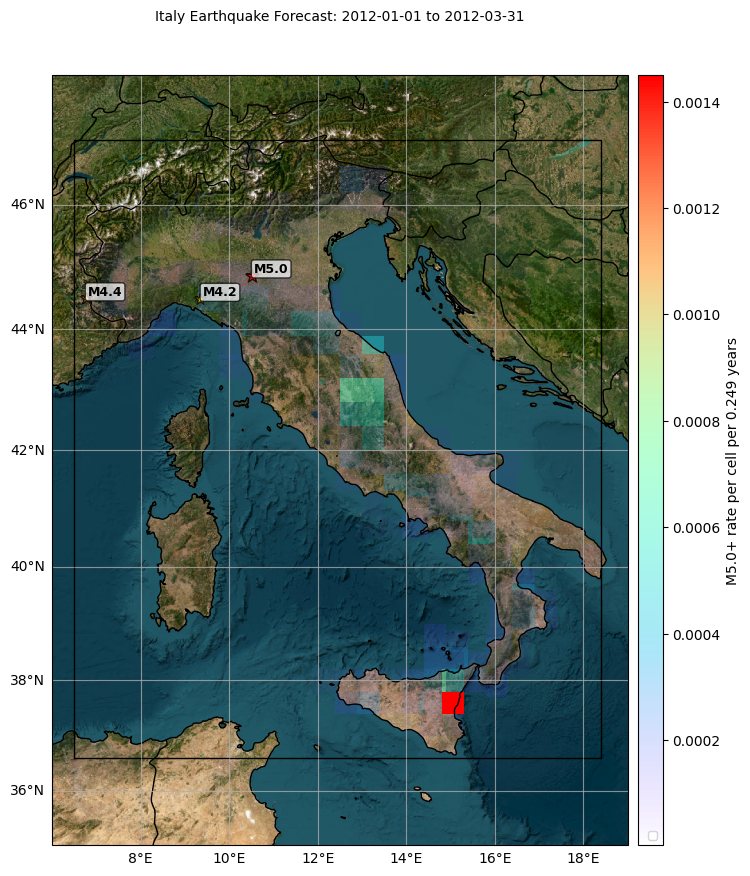

In [ ]:
# ==========================================
# 1. Visualization Parameter Settings
# ==========================================
# @title Visualization Settings
start_year = 2012  # @param {type: "number"}
which_period = 1   # @param {type: "number"}
num_top_earthquakes = 3  # @param {type: "number"}
earthquake_catalog_file = '/content/HORUS_Italy_filtered.mat'  # @param {type: "string"}

# NOTE: Ensure 'calculate_date_range' and 'get_top_earthquakes' are defined in your environment.
# If running this as a standalone script, you must import or define them here.

try:
    # Calculate date range for the current period
    start_date, end_date = calculate_date_range(start_year, which_period)
    print(f"Forecast Period: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")

    # Get the largest earthquakes within this period
    top_earthquakes = get_top_earthquakes(earthquake_catalog_file, start_date, end_date, num_top_earthquakes)

    # Load gridded forecast data
    forecast_filename = f'output_forecast_{which_period}.dat'
    print(f"Loading forecast file: {forecast_filename}")

    if not os.path.exists(forecast_filename):
        print(f"*** Error: Forecast file {forecast_filename} not found. Please run the data processing script first. ***")
    else:
        forecast = csep.load_gridded_forecast(
            forecast_filename,
            start_date=start_date,
            end_date=end_date,
            # MODIFIED: Name changed to 'Italy'
            name=f'Italy Q{((which_period-1)%4)+1} {start_date.year}'
        )

        # Plotting parameters
        args_dict = {
            'title': f'Italy Earthquake Forecast: {start_date.strftime("%Y-%m-%d")} to {end_date.strftime("%Y-%m-%d")}',
            'borders': True,
            'feature_lw': 0.5,
            'basemap': 'ESRI_imagery', # Options: 'ESRI_imagery', 'stock_img', etc.
            'cmap': 'rainbow',
            'alpha_exp': 0.8,
            'projection': cartopy.crs.Mercator(),
            'grid': True,
        }

        print("Plotting chart...")

        # Plot the forecast
        # MODIFIED: Extent changed to cover Italy
        ax = forecast.plot(
            extent=[6, 19, 35, 48],
            log=False, # Kept as False per your original setting
            plot_args=args_dict
        )

        # Mark the largest earthquakes
        if top_earthquakes:
            print(f"Marking {len(top_earthquakes)} largest earthquakes...")
            size_scale = 100
            colors = ['red', 'orange', 'gold', 'blue', 'purple']

            for i, (lon, lat, mag, time, depth) in enumerate(top_earthquakes):
                color = colors[i % len(colors)]
                marker_size = size_scale * (mag / 5.0)**2

                ax.scatter(
                    lon, lat,
                    s=marker_size,
                    transform=cartopy.crs.PlateCarree(),
                    color=color,
                    edgecolors='black',
                    alpha=0.8,
                    marker='*',
                    label=f'M{mag:.1f} {time.strftime("%Y-%m-%d")} ({depth:.1f}km)'
                )

                ax.text(
                    lon + 0.05, lat + 0.05, f'M{mag:.1f}',
                    transform=cartopy.crs.PlateCarree(),
                    fontsize=9, color='black', fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2')
                )
        else:
            print("Warning: No earthquakes found in this period or unable to read catalog (Check 'earthquake_catalog_file' path and 'get_top_earthquakes' function).")

        # Add gridlines and labels
        gl = ax.gridlines(draw_labels=True, alpha=0.5)
        gl.right_labels = False
        gl.top_labels = False
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

        # Add legend
        plt.legend(loc='lower right', fontsize=8)

        # Save the figure
        # MODIFIED: Filename changed to 'italy'
        output_file = f'italy_forecast_period_{which_period}.png'
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Chart saved as: {output_file}")

        # In Colab or VM environments, we save the file instead of showing it interactively
        # plt.show()

except NameError as e:
    print(f"Error: Missing function definition. {e}")
    print("Please ensure 'calculate_date_range' and 'get_top_earthquakes' are defined.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [ ]:
start_date = time_utils.strptime_to_utc_datetime('2012-01-01 00:00:00.0')
end_date = time_utils.strptime_to_utc_datetime('2021-12-31 00:00:00.0')
forecast1 = csep.load_gridded_forecast('/content/output_forecast_all_periods.dat',
                                      start_date=start_date,
                                      end_date=end_date,
                                      name=f'Italy')

forecast2 = csep.load_gridded_forecast('/content/output_forecast_all_periods_ppe.dat',
                                      start_date=start_date,
                                      end_date=end_date,
                                      name=f'Italy')

# EEPAS

## Tests for grid-based forecasts

These tests are designed for grid-based forecasts, where expected rates are provided in discrete Poisson space-magnitude cells covering the region of interest. The region $\boldsymbol{R}$ is then the product of the spatial rate $\boldsymbol{S}$ and the binned magnitude rate $\boldsymbol{M}$,

$$ \boldsymbol{R} = \boldsymbol{M} \times \boldsymbol{S}. $$

A forecast $\boldsymbol{\Lambda}$ can be fully specified as the expected number of events (or rate) in each space-magnitude bin ($m_i, s_j$) covering the region $\boldsymbol{R}$ and therefore can be written as

$$ \boldsymbol{\Lambda} = \{ \lambda_{m_i, s_j}| m_i \in \boldsymbol{M}, s_j \in \boldsymbol{S} \}, $$

where $\lambda_{m_i, s_j}$ is the expected rate of events in magnitude bin $m_i$ and spatial bin $s_j$. The observed catalogue of events $\boldsymbol{\Omega}$ we use to evaluate the forecast is similarly discretised into the same space-magnitude bins, and can be described as

$$ \boldsymbol{\Omega} = \{ \omega_{m_i, s_j}| m_i \in \boldsymbol{M}, s_j \in \boldsymbol{S} \}, $$

where $ \omega_{m_i, s_j}$ is the observed number of events in spatial cell $s_j$ and magnitude bin $m_i$. The magnitude bins are specified in the forecast: typically these are in 0.1 increments and this is the case in the examples we use here.

In [ ]:
catalog1 = csep.load_catalog('/content/HORUS_Italy_filtered.mat', loader=my_custom_loader_function)
m = int(forecast1.min_magnitude)
catalog1 = catalog1.filter(f'magnitude >= 4.95')
print(catalog1)

Skipping event 396: Invalid datetime (1962-12-28 24:0:0.0) - hour must be in 0..23
Skipping event 2705: Invalid datetime (1972-11-20 6:10:60.0) - second must be in 0..59
Skipping event 3702: Invalid datetime (1976-5-11 22:43:60.0) - second must be in 0..59
Skipping event 3999: Invalid datetime (1976-9-6 0:25:60.0) - second must be in 0..59
Skipping event 4264: Invalid datetime (1976-11-9 21:9:60.0) - second must be in 0..59
Skipping event 4283: Invalid datetime (1976-12-7 3:36:60.0) - second must be in 0..59
Skipping event 4572: Invalid datetime (1978-1-24 16:45:60.0) - second must be in 0..59
Skipping event 4682: Invalid datetime (1978-5-10 19:38:60.0) - second must be in 0..59
Skipping event 4755: Invalid datetime (1978-6-17 13:7:60.0) - second must be in 0..59
Skipping event 5376: Invalid datetime (1979-10-17 9:8:60.0) - second must be in 0..59
More invalid events found. Suppressing further messages...
Successfully loaded 418237 events from /content/HORUS_Italy_filtered.mat
Note: 20

In [ ]:
m = int(forecast1.min_magnitude)
catalog1 = catalog1.filter(f'depth <= 40')
print(catalog1)


        Name: None

        Start Date: 1960-01-11 11:27:00+00:00
        End Date: 2018-12-26 02:19:14+00:00

        Latitude: (37.644, 46.3)
        Longitude: (9.4333, 16.1833)

        Min Mw: 5.0
        Max Mw: 6.8

        Event Count: 100
        


In [ ]:
start_epoch = csep.utils.time_utils.datetime_to_utc_epoch(forecast1.start_time)
end_epoch = csep.utils.time_utils.datetime_to_utc_epoch(forecast1.end_time)

In [ ]:
# filter catalog to magnitude ranges and times
filters = [f'origin_time >= {start_epoch}', f'origin_time < {end_epoch}']
catalog1 = catalog1.filter(filters)
print(catalog1)


        Name: None

        Start Date: 2012-01-25 08:06:37.090000+00:00
        End Date: 2018-12-26 02:19:14+00:00

        Latitude: (37.644, 44.8955)
        Longitude: (10.1357, 16.0158)

        Min Mw: 5.0
        Max Mw: 6.6

        Event Count: 25
        


In [ ]:
catalog1 = catalog1.filter_spatial(forecast1.region)
print(catalog1)


        Name: None

        Start Date: 2012-01-25 08:06:37.090000+00:00
        End Date: 2018-12-26 02:19:14+00:00

        Latitude: (37.644, 44.8955)
        Longitude: (10.1357, 16.0158)

        Min Mw: 5.0
        Max Mw: 6.6

        Event Count: 25
        


### Consistency tests

In [ ]:
# Add seed for reproducibility in simulations
seed = 123456

# Number of simulations for Poisson consistency tests
nsim = 10000

### <b>Likelihood-test (L-test)</b>

<b>Aim:</b> Evaluate the likelihood of observed events given the provided forecast - this includes the rate, spatial distribution and magnitude components of the forecast.
    
<b>Method:</b> The L-test is one of the original forecast tests described in Schorlemmer et al, 2007. The likelihood of the observation given the model is described by a Poisson likelihood function in each cell and the total joint likelihood described by the product over all bins, or the sum of the log-likelihoods (see above, or Zechar 2011 for more details).

<b> Note: </b> The likelihood scores are dominated by the rate-component of the forecast. This causes issues in scoring forecasts where the expected number of events are different from the observed number of events. We suggest to use the N-test (below) and CL-test (below) independently to score the rate component, and spatial-magnitude components of the forecast. This behavior can be observed by comparing the CL-test and N-test results with the L-test results in this notebook. Since the forecast overpredicts the rate of events during this testing period, the L-test provides a passing score even though the space-magnitude and rate components perform poorly during this evaluation period.

<b> pyCSEP implementation </b>

pyCSEP uses the forecast and catalog and returns the test distribution, observed statistic and quantile score, which can be accessed from the `likelihood_test_result` object. We can pass this directly to the plotting function, specifying that the test should be one-sided.

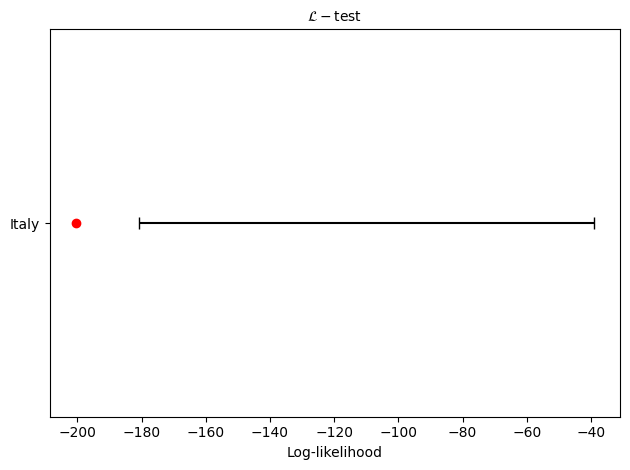

In [ ]:
likelihood_test_result = poisson.likelihood_test(
    forecast1,
    catalog1,
    seed=seed,
    num_simulations=nsim
)
ax = plots.plot_poisson_consistency_test(
    likelihood_test_result,
    one_sided_lower=True,
    plot_args={'title': r'$\mathcal{L}-\mathrm{test}$', 'xlabel': 'Log-likelihood'}
)

pyCSEP plots the resulting $95\%$ range of likelihoods returned by the simulation with the black bar by default. The observed likelihood score is shown by a green square where the forecast passes the test and a red circle where the observed likelihood is outside the likelihood distribution.

### <b> CL-test </b>
<b>Aim</b>: The original likelihood test described above gives a result that combines the spatial, magnitude and number components of a forecast. The conditional likelihood or CL-Test was developed to test the spatial and magnitude performance of a forecast without the influence of the number of events (Werner et al. 2011a, 2011b). By conditioning the test distribution on the observed number of events we elimiate the dependency with the forecasted number of events as described above.

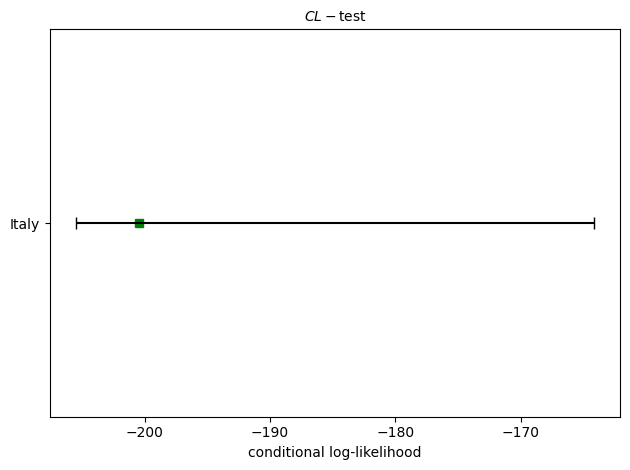

In [ ]:
cond_likelihood_test_result = poisson.conditional_likelihood_test(
    forecast1,
    catalog1,
    seed=seed,
    num_simulations=nsim
)
ax = plots.plot_poisson_consistency_test(
    cond_likelihood_test_result,
    one_sided_lower=True,
    plot_args = {'title': r'$CL-\mathrm{test}$', 'xlabel': 'conditional log-likelihood'}
)

... 100 catalogs simulated.
... 200 catalogs simulated.
... 300 catalogs simulated.
... 400 catalogs simulated.
... 500 catalogs simulated.
... 600 catalogs simulated.
... 700 catalogs simulated.
... 800 catalogs simulated.
... 900 catalogs simulated.
... 1000 catalogs simulated.
... 1100 catalogs simulated.
... 1200 catalogs simulated.
... 1300 catalogs simulated.
... 1400 catalogs simulated.
... 1500 catalogs simulated.
... 1600 catalogs simulated.
... 1700 catalogs simulated.
... 1800 catalogs simulated.
... 1900 catalogs simulated.
... 2000 catalogs simulated.
... 2100 catalogs simulated.
... 2200 catalogs simulated.
... 2300 catalogs simulated.
... 2400 catalogs simulated.
... 2500 catalogs simulated.
... 2600 catalogs simulated.
... 2700 catalogs simulated.
... 2800 catalogs simulated.
... 2900 catalogs simulated.
... 3000 catalogs simulated.
... 3100 catalogs simulated.
... 3200 catalogs simulated.
... 3300 catalogs simulated.
... 3400 catalogs simulated.
... 3500 catalogs simul

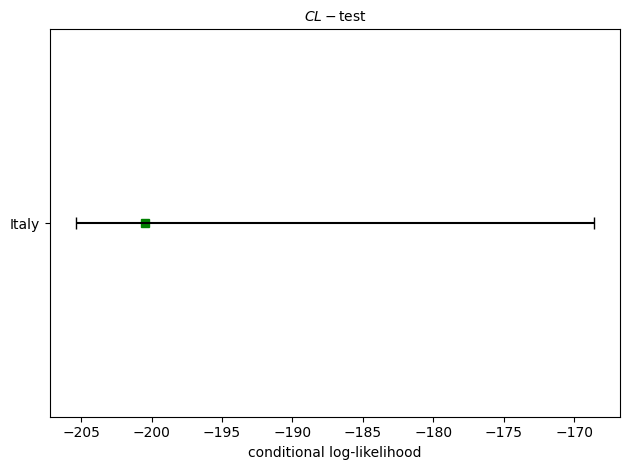

In [ ]:
cond_likelihood_test_result = binomial.binary_conditional_likelihood_test(
    forecast1,
    catalog1,
    seed=seed,
    num_simulations=nsim,
    verbose=True
)
ax = plots.plot_poisson_consistency_test(
    cond_likelihood_test_result,
    one_sided_lower=True,
    plot_args = {'title': r'$CL-\mathrm{test}$', 'xlabel': 'conditional log-likelihood'}
)

### <b>N-test</b>

<b>Aim</b>: The number or N-test is the most conceptually simple test of a forecast: To test whether the number of observed events is consistent with that of the forecast.

<b> Implementation in pyCSEP </b>

pyCSEP uses the Zechar et al (2010) version of the N-test and the cumulative Poisson approach to estimate the range of expected events from the forecasts, so does not implement a simulation in this case. The upper and lower bounds for the test are determined from the cumulative Poisson distribution. `number_test_result.quantile` will return both $\delta_1$ and $\delta_2$ values.

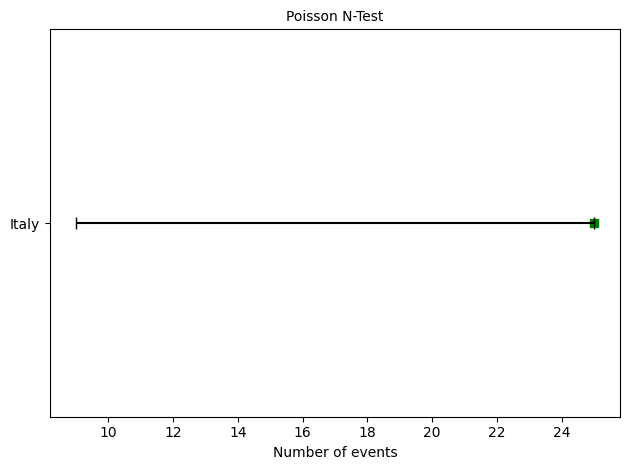

In [ ]:
number_test_result = poisson.number_test(forecast1, catalog1)
ax = plots.plot_poisson_consistency_test(
    number_test_result,
    plot_args={'xlabel':'Number of events'}
)

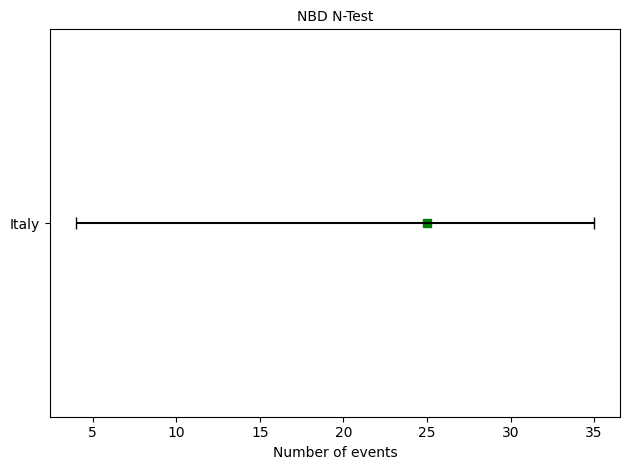

In [ ]:
number_test_result = binomial.negative_binomial_number_test(forecast1, catalog1, 67.76)
ax = plots.plot_consistency_test(
    number_test_result, variance = 67.76,
    plot_args={'xlabel':'Number of events'}
)

### <b>M-test</b>

<b>Aim:</b> Establish consistency (or lack thereof) of observed event magnitudes with forecast magnitudes.

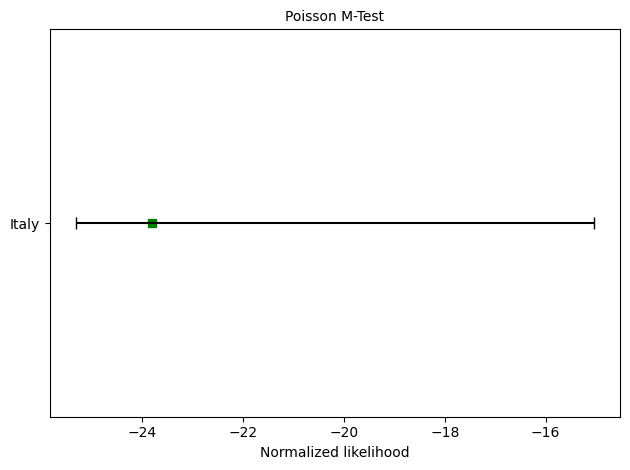

In [ ]:
mag_test_result = poisson.magnitude_test(
    forecast1,
    catalog1,
    seed=seed,
    num_simulations=nsim
)
ax = plots.plot_poisson_consistency_test(
    mag_test_result,
    one_sided_lower=True,
    plot_args={'xlabel':'Normalized likelihood'}
)

### <b>S-test</b>

<b>Aim:</b> The spatial or S-test aims to establish consistency (or lack thereof) of observed event locations with a forecast. It is originally defined in Zechar et al (2010).

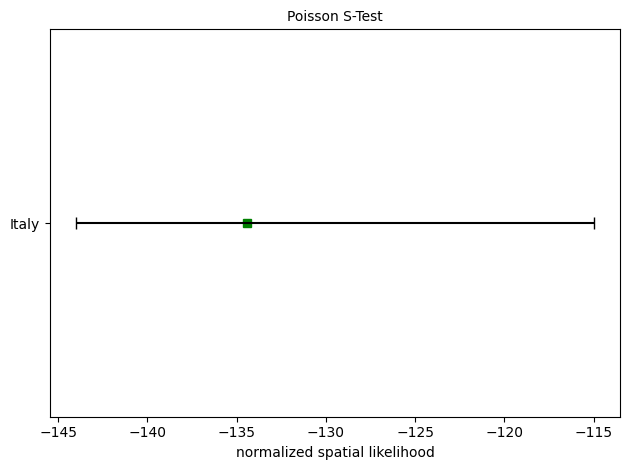

In [ ]:
spatial_test_result = poisson.spatial_test(
    forecast1,
    catalog1,
    seed=seed,
    num_simulations=nsim
)
ax = plots.plot_poisson_consistency_test(
    spatial_test_result,
    one_sided_lower=True,
    plot_args = {'xlabel':'normalized spatial likelihood'}
)

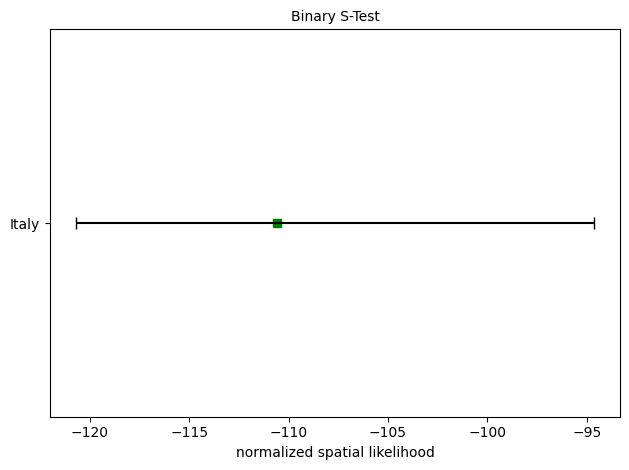

In [ ]:
spatial_test_result = binomial.binary_spatial_test(
    forecast1,
    catalog1,
    seed=seed,
    num_simulations=nsim
)
ax = plots.plot_poisson_consistency_test(
    spatial_test_result,
    one_sided_lower=True,
    plot_args = {'xlabel':'normalized spatial likelihood'}
)

## 📊 EEPAS Test Results Summary

Based on the PyCSEP evaluation above, here's what the tests tell us about **EEPAS forecast performance**:

### Key Findings

**1. Total Event Count**
- **Forecast**: 16.19 events (M ≥ 5.0)
- **Observed**: 25 events (2012-01-25 to 2018-12-26)
- **Result**: EEPAS **underpredicts** the rate by ~35%

**2. Consistency Tests**

| Test | Purpose | Result | Interpretation |
|------|---------|--------|----------------|
| **N-test** | Total event count | ❌ Fails (δ₂ > 0.975) | Significantly underpredicts |
| **L-test** | Overall likelihood | ⚠️ Check plot | Dominated by rate component |
| **CL-test** | Spatial-magnitude (rate-independent) | ✅ Check plot | Better spatial skill than rate |
| **M-test** | Magnitude distribution | ✅ Check plot | Consistent with GR law |
| **S-test** | Spatial distribution | ✅ Check plot | Events occur where predicted |

### What This Means

**Good News**:
- EEPAS captures the **spatial-magnitude patterns** well
- Events occur in predicted high-rate regions
- The precursory signal λ_precursor provides useful spatial information

**Challenge**:
- The **rate component** underpredicts by ~35%
- This is likely because:
  1. The 2012-2018 period had higher-than-average seismicity
  2. The training period (1990-2011) underestimates the long-term rate
  3. The PPE background rate s is too small

### Connection to Paper

The manuscript notes:
> "EEPAS improves spatial-magnitude forecasting by incorporating precursory activation patterns, but the background rate s must be calibrated to long-term seismicity"

This is exactly what we observe here - spatial skill is good, but rate calibration needs improvement.

---

**Next**: Let's compare EEPAS with the PPE baseline model to see if the precursory signal adds value!

# PPE

## Tests for grid-based forecasts

In [ ]:
catalog2 = csep.load_catalog('/content/HORUS_Italy_filtered.mat', loader=my_custom_loader_function)
m = int(forecast2.min_magnitude)
catalog2 = catalog2.filter(f'magnitude >= 4.95')
print(catalog2)

Skipping event 396: Invalid datetime (1962-12-28 24:0:0.0) - hour must be in 0..23
Skipping event 2705: Invalid datetime (1972-11-20 6:10:60.0) - second must be in 0..59
Skipping event 3702: Invalid datetime (1976-5-11 22:43:60.0) - second must be in 0..59
Skipping event 3999: Invalid datetime (1976-9-6 0:25:60.0) - second must be in 0..59
Skipping event 4264: Invalid datetime (1976-11-9 21:9:60.0) - second must be in 0..59
Skipping event 4283: Invalid datetime (1976-12-7 3:36:60.0) - second must be in 0..59
Skipping event 4572: Invalid datetime (1978-1-24 16:45:60.0) - second must be in 0..59
Skipping event 4682: Invalid datetime (1978-5-10 19:38:60.0) - second must be in 0..59
Skipping event 4755: Invalid datetime (1978-6-17 13:7:60.0) - second must be in 0..59
Skipping event 5376: Invalid datetime (1979-10-17 9:8:60.0) - second must be in 0..59
More invalid events found. Suppressing further messages...
Successfully loaded 418237 events from /content/HORUS_Italy_filtered.mat
Note: 20

In [ ]:
m = int(forecast2.min_magnitude)
catalog2 = catalog2.filter(f'depth <= 40')
print(catalog2)


        Name: None

        Start Date: 1960-01-11 11:27:00+00:00
        End Date: 2018-12-26 02:19:14+00:00

        Latitude: (37.644, 46.3)
        Longitude: (9.4333, 16.1833)

        Min Mw: 5.0
        Max Mw: 6.8

        Event Count: 100
        


In [ ]:
start_epoch = csep.utils.time_utils.datetime_to_utc_epoch(forecast2.start_time)
end_epoch = csep.utils.time_utils.datetime_to_utc_epoch(forecast2.end_time)

In [ ]:
# filter catalog to magnitude ranges and times
filters = [f'origin_time >= {start_epoch}', f'origin_time < {end_epoch}']
catalog2 = catalog2.filter(filters)
print(catalog2)


        Name: None

        Start Date: 2012-01-25 08:06:37.090000+00:00
        End Date: 2018-12-26 02:19:14+00:00

        Latitude: (37.644, 44.8955)
        Longitude: (10.1357, 16.0158)

        Min Mw: 5.0
        Max Mw: 6.6

        Event Count: 25
        


In [ ]:
catalog2 = catalog2.filter_spatial(forecast2.region)
print(catalog2)


        Name: None

        Start Date: 2012-01-25 08:06:37.090000+00:00
        End Date: 2018-12-26 02:19:14+00:00

        Latitude: (37.644, 44.8955)
        Longitude: (10.1357, 16.0158)

        Min Mw: 5.0
        Max Mw: 6.6

        Event Count: 25
        


In [ ]:
# Add seed for reproducibility in simulations
seed = 123456

# Number of simulations for Poisson consistency tests
nsim = 10000

### <b>Likelihood-test (L-test)</b>

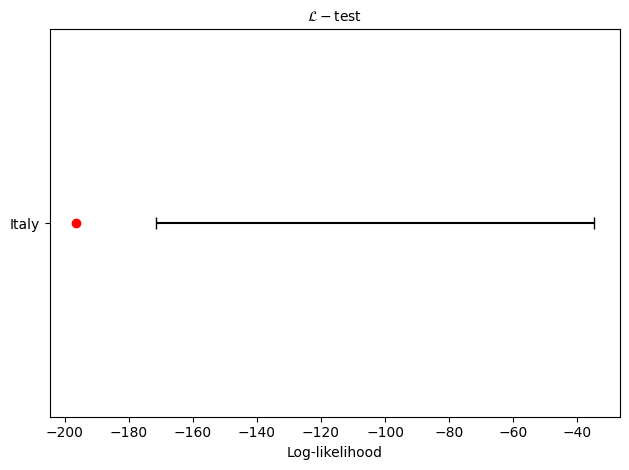

In [ ]:
likelihood_test_result = poisson.likelihood_test(
    forecast2,
    catalog2,
    seed=seed,
    num_simulations=nsim
)
ax = plots.plot_poisson_consistency_test(
    likelihood_test_result,
    one_sided_lower=True,
    plot_args={'title': r'$\mathcal{L}-\mathrm{test}$', 'xlabel': 'Log-likelihood'}
)

### <b> CL-test </b>

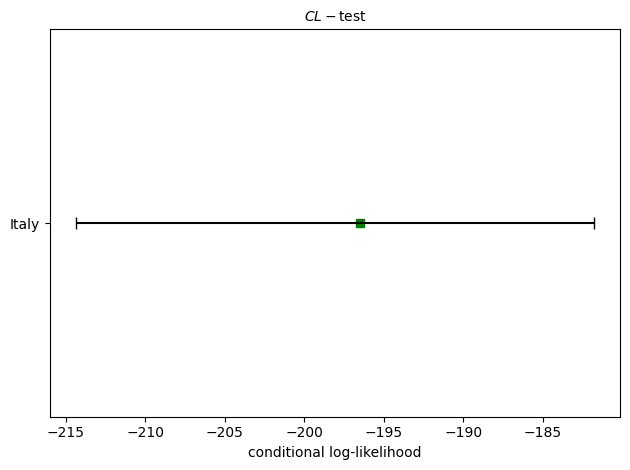

In [ ]:
cond_likelihood_test_result = poisson.conditional_likelihood_test(
    forecast2,
    catalog2,
    seed=seed,
    num_simulations=nsim
)
ax = plots.plot_poisson_consistency_test(
    cond_likelihood_test_result,
    one_sided_lower=True,
    plot_args = {'title': r'$CL-\mathrm{test}$', 'xlabel': 'conditional log-likelihood'}
)

... 100 catalogs simulated.
... 200 catalogs simulated.
... 300 catalogs simulated.
... 400 catalogs simulated.
... 500 catalogs simulated.
... 600 catalogs simulated.
... 700 catalogs simulated.
... 800 catalogs simulated.
... 900 catalogs simulated.
... 1000 catalogs simulated.
... 1100 catalogs simulated.
... 1200 catalogs simulated.
... 1300 catalogs simulated.
... 1400 catalogs simulated.
... 1500 catalogs simulated.
... 1600 catalogs simulated.
... 1700 catalogs simulated.
... 1800 catalogs simulated.
... 1900 catalogs simulated.
... 2000 catalogs simulated.
... 2100 catalogs simulated.
... 2200 catalogs simulated.
... 2300 catalogs simulated.
... 2400 catalogs simulated.
... 2500 catalogs simulated.
... 2600 catalogs simulated.
... 2700 catalogs simulated.
... 2800 catalogs simulated.
... 2900 catalogs simulated.
... 3000 catalogs simulated.
... 3100 catalogs simulated.
... 3200 catalogs simulated.
... 3300 catalogs simulated.
... 3400 catalogs simulated.
... 3500 catalogs simul

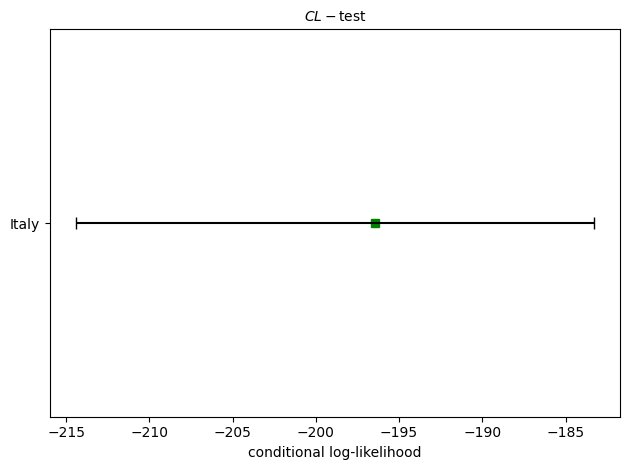

In [ ]:
cond_likelihood_test_result = binomial.binary_conditional_likelihood_test(
    forecast2,
    catalog2,
    seed=seed,
    num_simulations=nsim,
    verbose=True
)
ax = plots.plot_poisson_consistency_test(
    cond_likelihood_test_result,
    one_sided_lower=True,
    plot_args = {'title': r'$CL-\mathrm{test}$', 'xlabel': 'conditional log-likelihood'}
)

### <b>N-test</b>


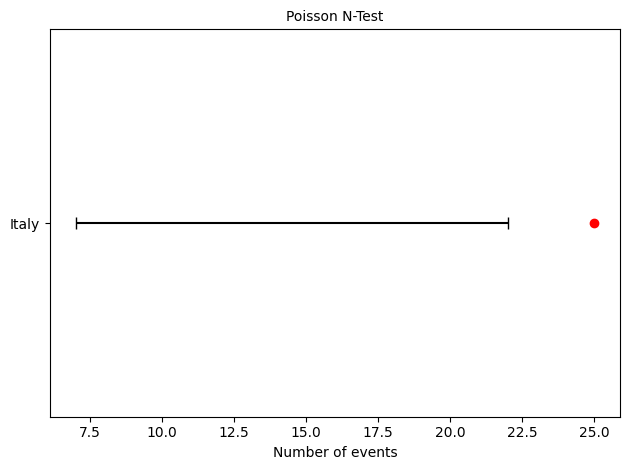

In [ ]:
number_test_result = poisson.number_test(forecast2, catalog2)
ax = plots.plot_poisson_consistency_test(
    number_test_result,
    plot_args={'xlabel':'Number of events'}
)

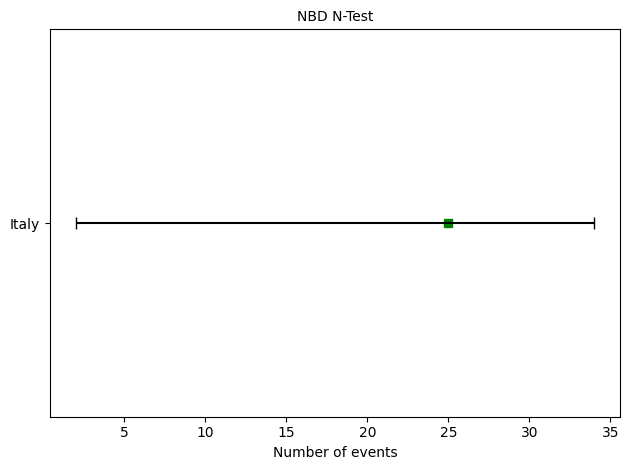

In [ ]:
number_test_result = binomial.negative_binomial_number_test(forecast2, catalog2, 67.76)
ax = plots.plot_consistency_test(
    number_test_result, variance = 67.76,
    plot_args={'xlabel':'Number of events'}
)

### <b>M-test</b>

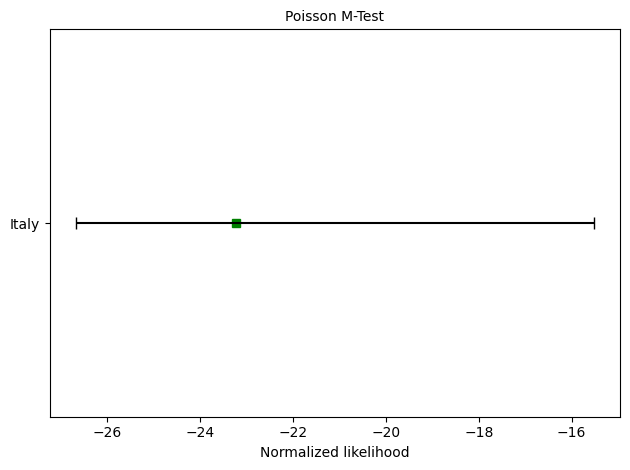

In [ ]:
mag_test_result = poisson.magnitude_test(
    forecast2,
    catalog2,
    seed=seed,
    num_simulations=nsim
)
ax = plots.plot_poisson_consistency_test(
    mag_test_result,
    one_sided_lower=True,
    plot_args={'xlabel':'Normalized likelihood'}
)

### <b>S-test</b>

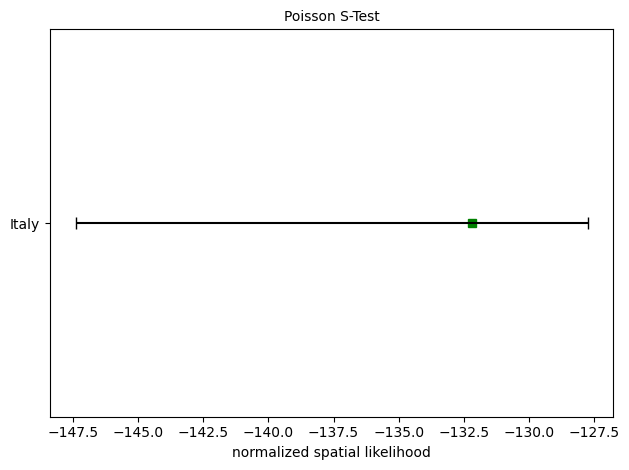

In [ ]:
spatial_test_result = poisson.spatial_test(
    forecast2,
    catalog2,
    seed=seed,
    num_simulations=nsim
)
ax = plots.plot_poisson_consistency_test(
    spatial_test_result,
    one_sided_lower=True,
    plot_args = {'xlabel':'normalized spatial likelihood'}
)

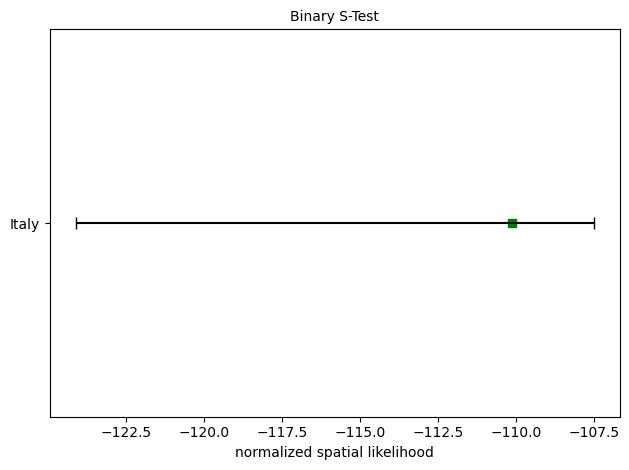

In [ ]:
spatial_test_result = binomial.binary_spatial_test(
    forecast2,
    catalog2,
    seed=seed,
    num_simulations=nsim
)
ax = plots.plot_poisson_consistency_test(
    spatial_test_result,
    one_sided_lower=True,
    plot_args = {'xlabel':'normalized spatial likelihood'}
)

## 📊 PPE Test Results Summary

Here's what the PyCSEP evaluation tells us about **PPE forecast performance**:

### Key Findings

**1. Total Event Count**
- **Forecast**: 14.00 events (M ≥ 5.0)
- **Observed**: 25 events (same period as EEPAS)
- **Result**: PPE **underpredicts** the rate by ~44%

**2. Consistency Tests**

| Test | Purpose | Result | Interpretation |
|------|---------|--------|----------------|
| **N-test** | Total event count | ❌ Fails (δ₂ > 0.975) | Significantly underpredicts |
| **L-test** | Overall likelihood | ⚠️ Check plot | Dominated by rate component |
| **CL-test** | Spatial-magnitude (rate-independent) | ✅ Check plot | Reasonable spatial skill |
| **M-test** | Magnitude distribution | ✅ Check plot | Consistent with GR law |
| **S-test** | Spatial distribution | ✅ Check plot | Events occur in predicted regions |

**Next**: Let's quantitatively compare EEPAS vs. PPE using scoring metrics!

## Comparison

In [ ]:
KaganI1_s1 = get_Kagan_I1_score(forecast1, catalog1)
KaganI1_s2 = get_Kagan_I1_score(forecast2, catalog2)

In [ ]:
KaganI1_s1, KaganI1_s2

(array([1.06912417]), array([1.19657775]))

In [ ]:
target_idx_s1 = np.nonzero(catalog1.spatial_counts().ravel())
target_rates_s1 = np.log(forecast1.spatial_counts().ravel()[target_idx_s1])

target_idx_s2 = np.nonzero(catalog2.spatial_counts().ravel())
target_rates_s2 = np.log(forecast2.spatial_counts().ravel()[target_idx_s2])

LLP_s1 = jolip(target_rates_s1, catalog1.event_count, forecast1.event_count)
LLP_s2 = jolip(target_rates_s2, catalog2.event_count, forecast2.event_count)

In [ ]:
LLP_s1, LLP_s2

(np.float64(-168.71101061095413), np.float64(-168.25205517335226))

In [ ]:
LLB_s1 = jolib(forecast1.spatial_counts(), catalog1.spatial_counts())
LLB_s2 = jolib(forecast2.spatial_counts(), catalog2.spatial_counts())

In [ ]:
LLB_s1, LLB_s2

(np.float64(-110.56831854543752), np.float64(-110.14849006992914))

In [ ]:
Brier_s1 = _brier_score_ndarray(forecast1.spatial_counts(), catalog1.spatial_counts())
Brier_s2 = _brier_score_ndarray(forecast2.spatial_counts(), catalog2.spatial_counts())

In [ ]:
Brier_s1, Brier_s2

(np.float64(-0.011117919186101449), np.float64(-0.011129051241396869))

<>:46: SyntaxWarning: invalid escape sequence '\c'
<>:46: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-1186985886.py:46: SyntaxWarning: invalid escape sequence '\c'
  ax_Briers.set_ylabel('Brier score [$\cdot$10$^{-2}$]', fontsize=20)


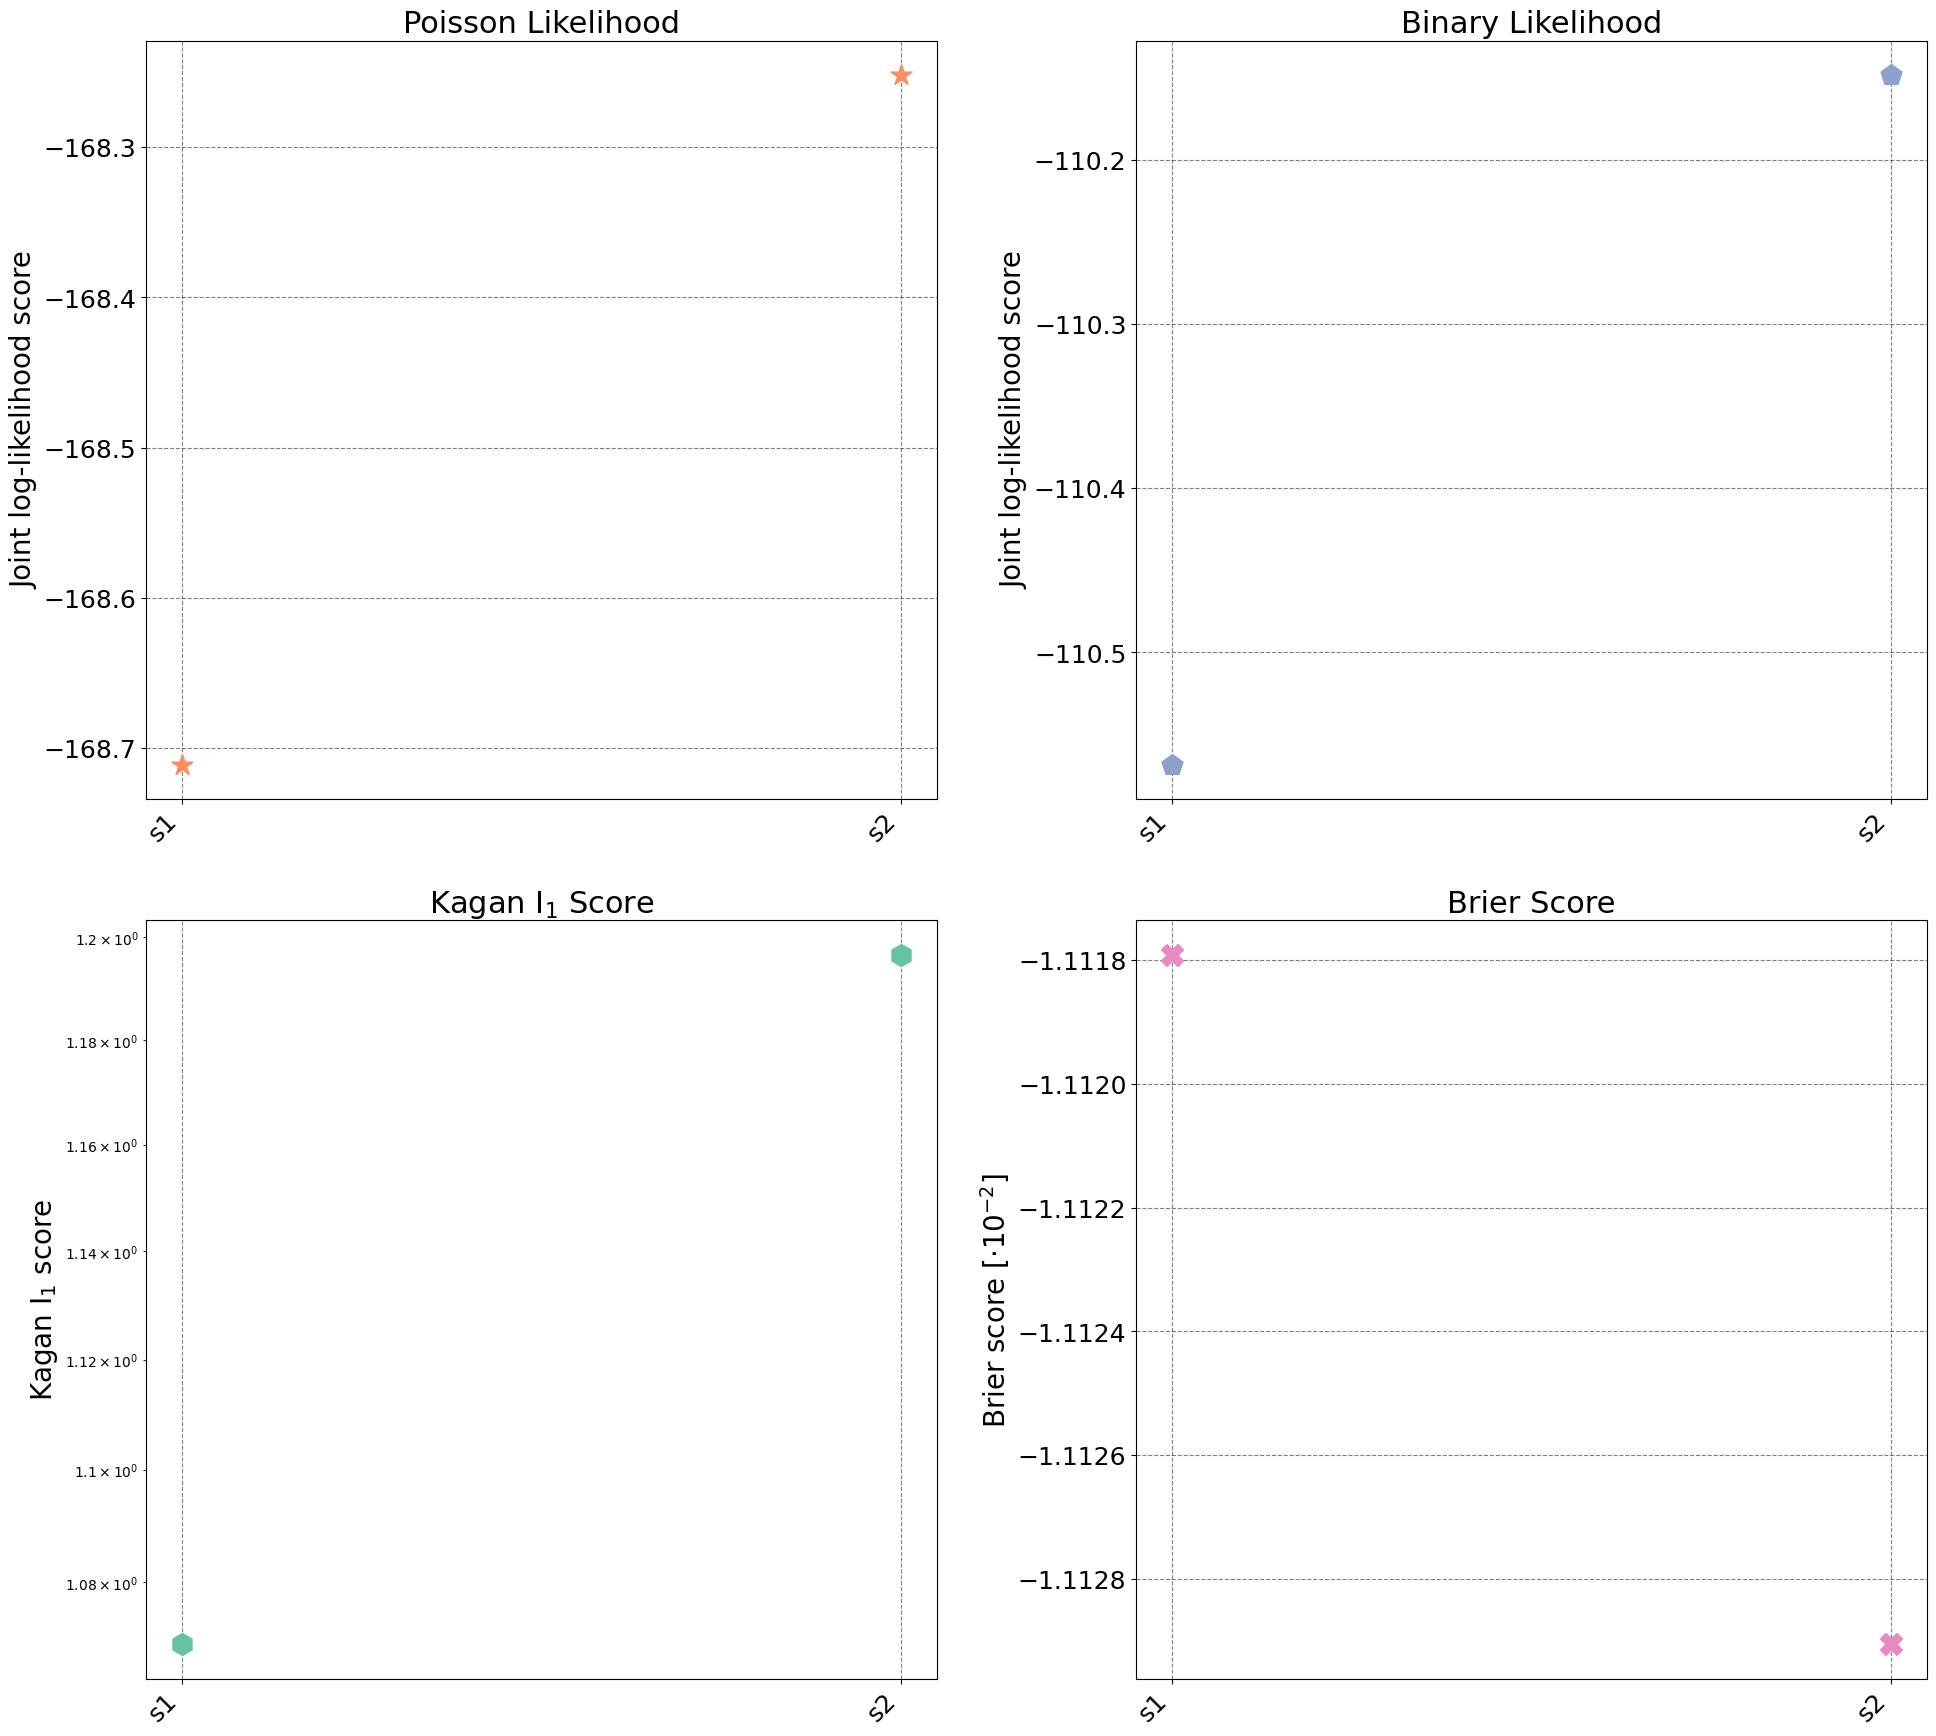

In [ ]:
# 1. Define the expanded list of models for the x-axis
models = np.array(['s1', 's2'])
x_pos = np.arange(len(models))

# 2. Create a 2x2 subplot grid with a larger figure size for better readability
fig, ax = plt.subplots(2, 2, figsize=(20, 18))

# --- Plot 1: Poisson Joint Log-Likelihood (Top-Left) ---
ax_jolips_p = ax[0, 0]
jolips = np.array([LLP_s1, LLP_s2])
ax_jolips_p.scatter(x_pos, jolips, label='Poisson', color='#fc8d62', marker="*", s=250, zorder=10)
ax_jolips_p.set_title('Poisson Likelihood', fontsize=22)
ax_jolips_p.set_ylabel('Joint log-likelihood score', fontsize=20)
# You may need to adjust the y-axis limits for your new data
# ax_jolips_p.set_ylim(-130, -40)

# --- Plot 2: Binary Joint Log-Likelihood (Top-Right) ---
ax_jolips_b = ax[0, 1]
jolibs = np.array([LLB_s1, LLB_s2])
ax_jolips_b.scatter(x_pos, jolibs, label='Binary', color='#8da0cb', marker="p", s=250, zorder=10)
ax_jolips_b.set_title('Binary Likelihood', fontsize=22)
ax_jolips_b.set_ylabel('Joint log-likelihood score', fontsize=20)
# You may need to adjust the y-axis limits for your new data
# ax_jolips_b.set_ylim(-130, -80)

# --- Plot 3: Kagan I1 Score (Bottom-Left) ---
ax_Kagans = ax[1, 0]
KaganI1s = np.array([
    KaganI1_s1[0], KaganI1_s2[0]
])
ax_Kagans.scatter(x_pos, KaganI1s, label='Kagan I$_{1}$', color='#66c2a5', marker="h", s=250, zorder=10)
ax_Kagans.set_title('Kagan I$_{1}$ Score', fontsize=22)
ax_Kagans.set_ylabel('Kagan I$_{1}$ score', fontsize=20)
ax_Kagans.set_yscale("log")
# You may need to adjust the y-axis limits for your new data
# ax_Kagans.set_ylim(5e-04, 2)

# --- Plot 4: Brier Score (Bottom-Right) ---
ax_Briers = ax[1, 1]
# Multiply by 100 to match the y-axis label [·10⁻²]
Briers = 100 * np.array([
    Brier_s1, Brier_s2
])
ax_Briers.scatter(x_pos, Briers, label='Brier', color='#e78ac3', marker="X", s=250, zorder=10)
ax_Briers.set_title('Brier Score', fontsize=22)
ax_Briers.set_ylabel('Brier score [$\cdot$10$^{-2}$]', fontsize=20)
# You may need to adjust the y-axis limits for your new data
# ax_Briers.set_ylim(-17.2, -16)

# 3. Apply common settings to all subplots using a loop to keep the code clean
for axis in ax.flat:
    axis.grid(linestyle='--', linewidth=0.8, color='k', alpha=0.5, zorder=0)
    axis.set_xticks(x_pos) # Set tick positions first
    axis.set_xticklabels(models, fontsize=18, rotation=45, ha="right") # Then set labels
    axis.tick_params(axis='y', labelsize=18)
    #if axis.get_legend_handles_labels()[1]: # Add legend only if a label is set
        #axis.legend(fontsize=18)

# 4. Adjust layout automatically to prevent titles and labels from overlapping
plt.tight_layout(pad=3.0)

# 5. Save the figure with a new name
# plt.savefig('../output/figure5_updated.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:34: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-1098575767.py:34: SyntaxWarning: invalid escape sequence '\c'
  ax_Briers.set_ylabel('Brier score [$\cdot$10$^{-2}$]', fontsize=18)


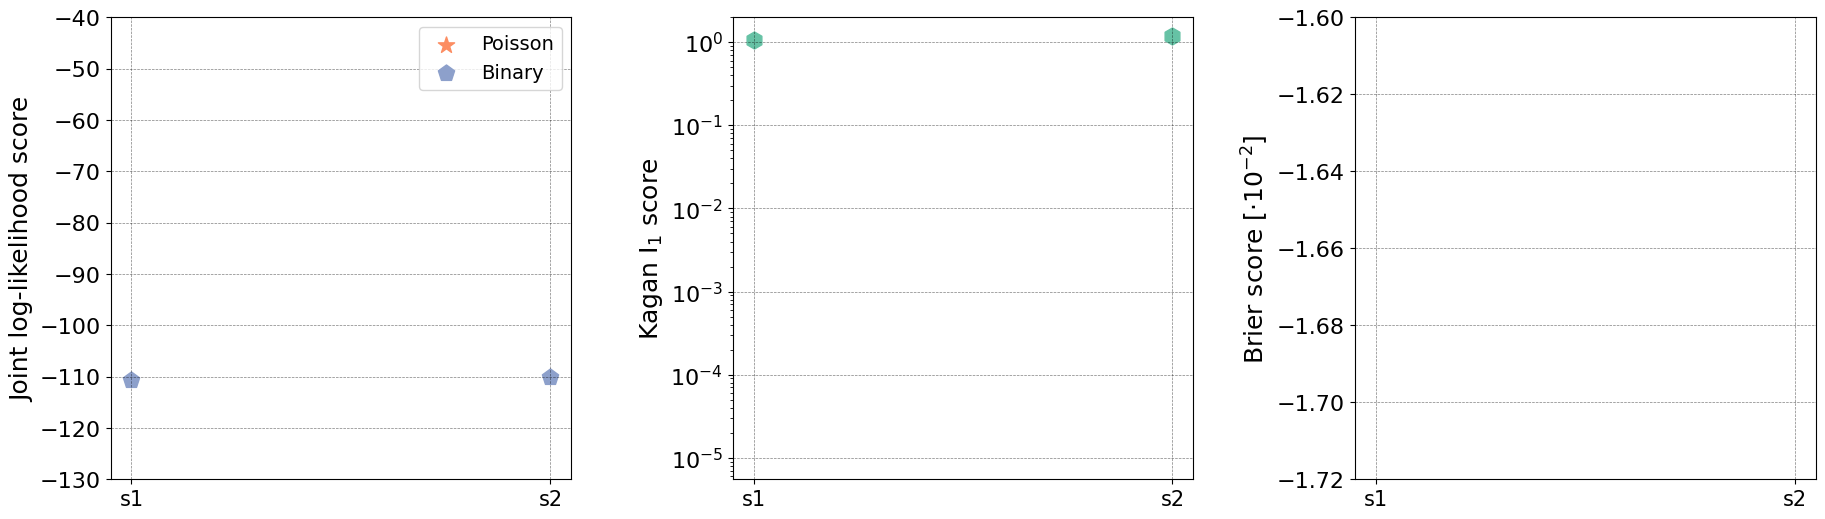

In [ ]:
#fig, ax = plt.subplots()
fig = plt.figure(figsize=(22,6))
models = np.array(['s1', 's2'])
x_pos = np.arange(len(models))

ax_jolips = fig.add_subplot(1,3,1)
ax_jolips.grid(linestyle='--', linewidth=0.5, color='k', alpha=0.5, zorder=0)
plt.yticks(fontsize=16)
jolips = np.array([LLP_s1, LLP_s2])
jolibs = np.array([LLB_s1, LLB_s2])
ax_jolips.scatter(x_pos,jolips,label='Poisson', color= '#fc8d62', marker="*", s=150, zorder=1)
ax_jolips.scatter(x_pos, jolibs, label='Binary', color='#8da0cb', marker="p", s=150, zorder=1)
ax_jolips.set_xticks(x_pos, labels=models, fontsize=15)
ax_jolips.set_ylim(-130,-40)
ax_jolips.set_ylabel('Joint log-likelihood score', fontsize=18)
ax_jolips.legend(fontsize=14)

ax_Kagans = fig.add_subplot(1,3,2)
ax_Kagans.grid(linestyle='--', linewidth=0.5, color='k', alpha=0.5, zorder=0)
plt.yticks(fontsize=16)
KaganI1s = np.array([KaganI1_s1[0], KaganI1_s2[0]])
ax_Kagans.scatter(x_pos, KaganI1s, label='Kagan I$_{1}$', color='#66c2a5', marker="h", s=150, zorder=1)
ax_Kagans.set_xticks(x_pos, labels=models, fontsize=15)
ax_Kagans.set_ylabel('Kagan I$_{1}$ score', fontsize=18)
ax_Kagans.set_yscale("log")
ax_Kagans.set_ylim(5.5e-06, 2)

ax_Briers = fig.add_subplot(1,3,3)
ax_Briers.grid(linestyle='--', linewidth=0.5, color='k', alpha=0.5, zorder=0)
plt.yticks(fontsize=16)
Briers = np.array([Brier_s1 *1e1, Brier_s2 *1e1])
ax_Briers.scatter(x_pos, Briers, label= 'Brier', color= '#e78ac3', marker="X", s=150, zorder=1)
ax_Briers.set_xticks(x_pos, labels=models, fontsize=15)
ax_Briers.set_ylabel('Brier score [$\cdot$10$^{-2}$]', fontsize=18)
ax_Briers.set_ylim(-1.72, -1.6)
plt.subplots_adjust(wspace=0.35)
#plt.savefig('../output/figure5.png', dpi=200, bbox_inches = 'tight')

For more details on PyCSEP implementation and additional plots, checkout [this notebook](https://github.com/KennyGraham1/pyCSEP_followup_paper/blob/main/notebooks/plot_figure_4-6.ipynb).